## Notebook Structure

1. Identifying the Prediction Target  
2. Data Loading and Exploration  
3. Initial Conceptual Screening of Features  
4. Data Splitting  
5. Managing Missing Values  
6. Encoding Categorical Variables  
7. Feature Scaling  
8. Feature Selection  
9. Addressing Class Imbalance  
10. Training a Logistic Regression Model  
11. Validation Results and Zero Rule Comparison  
12. Task Ordering Justification  
13. Final Discussion and Limitations

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

## 1. Identifying the Prediction Target

The objective of the marketing campaign is to determine whether a contacted client subscribes to a term deposit. In the dataset, this outcome is represented by the variable `y`, which takes the values `"yes"` and `"no"`.

Therefore, `y` is the appropriate prediction target for this assignment. The machine learning task is a **binary classification problem**, where the goal is to predict whether a client subscribes to a term deposit using the available demographic, financial, campaign-related, and macroeconomic information.

In [2]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [3]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


### Why Other Variables Are Not Appropriate Prediction Targets

Some variables in the dataset might superficially appear to be possible targets but do not correspond to the actual prediction objective.

- **`duration`** is the length of the phone call. It may be highly predictive, but it is only known after the call has finished. Because the prediction should be made at the time of contact, treating `duration` as the target or even as a regular predictor would be conceptually incorrect for this assignment.
- **`campaign`** indicates the number of contacts performed during the campaign for a client. It describes campaign activity, not the business outcome of interest.

For these reasons, `y` remains the correct prediction target.

In [4]:
print("Target distribution:")
display(df["y"].value_counts())
display(df["y"].value_counts(normalize=True))

Target distribution:


y
no     3668
yes     451
Name: count, dtype: int64

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

## 2. Data Loading and Exploration

Before performing any preprocessing or modeling, it is necessary to inspect the structure and characteristics of the dataset. The goal of this stage is to understand the number of observations, the number of features, the variable types, the distribution of the target, and possible missingness patterns.

This stage is descriptive only. No transformation is fitted yet.

In [5]:
print("Dataset shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nNumerical summary statistics:")
display(df.describe())

print("\nCategorical summary statistics:")
display(df.describe(include="object"))

Dataset shape: (4119, 21)

Data types:


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


Numerical summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Categorical summary statistics:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [6]:
numerical_cols_full = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_full = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical variables:")
print(numerical_cols_full)

print("\nCategorical variables:")
print(categorical_cols_full)

Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset contains both numerical and categorical variables.

- Numerical variables include attributes such as `age`, `campaign`, `pdays`, and the macroeconomic indicators.
- Categorical variables include `job`, `marital`, `education`, `contact`, and `poutcome`.

These categorical variables will later require encoding before they can be used by Logistic Regression.

In [7]:
print("Explicit missing values per column:")
display(df.isna().sum())

Explicit missing values per column:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

There are no obvious explicit missing values represented as `NaN` in the raw dataset. However, this does not imply the absence of missingness. In this dataset, missing information may also appear implicitly through categories such as `"unknown"` or through sentinel numerical codes such as `pdays = 999`.

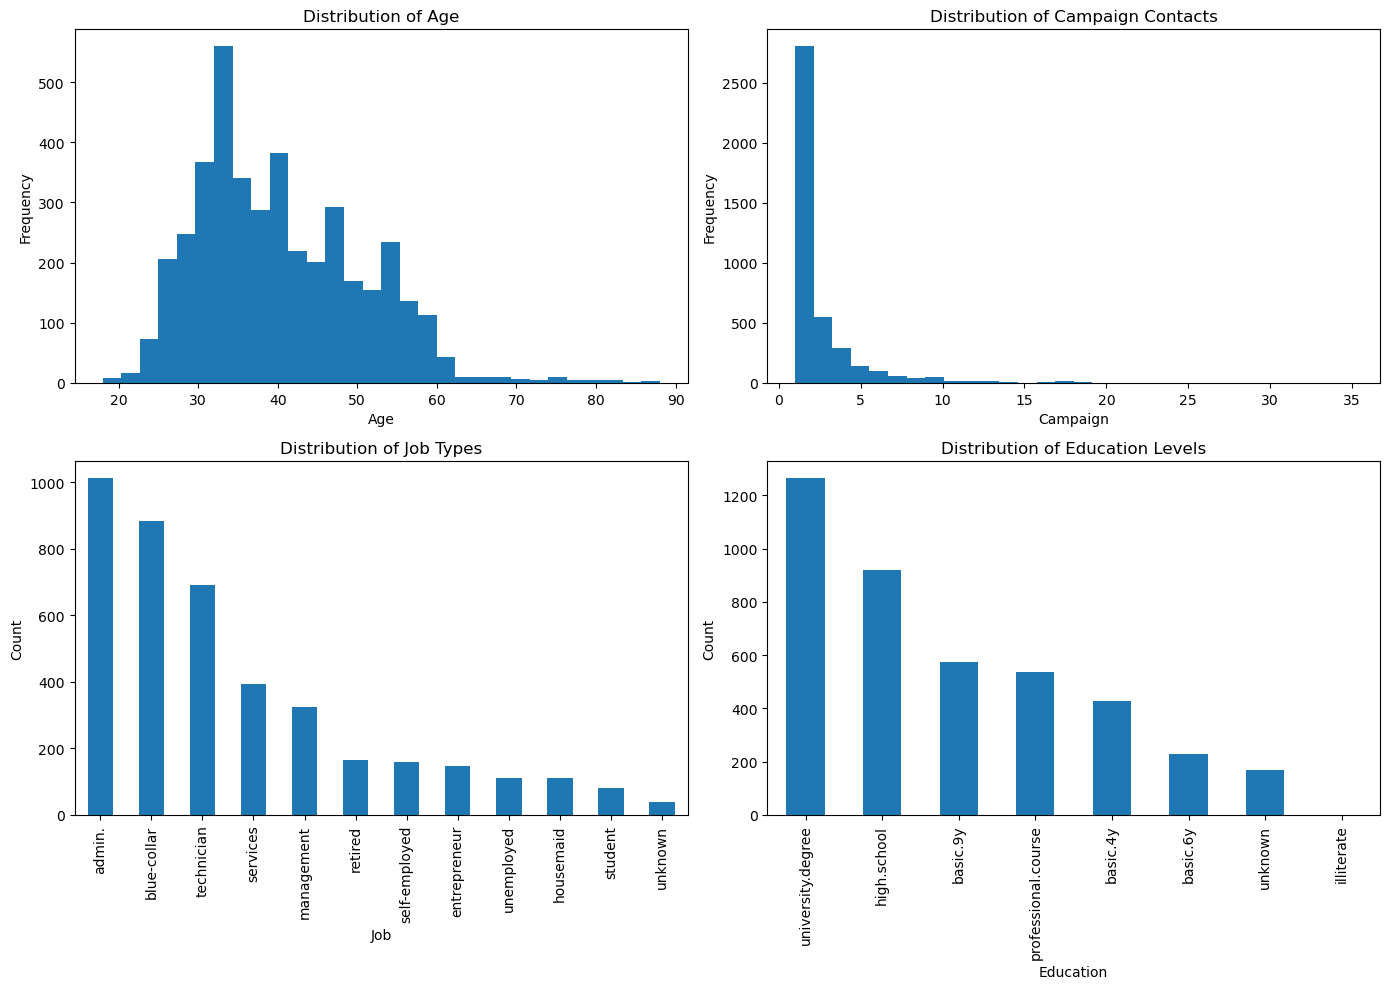

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Numerical variable 1
axes[0, 0].hist(df["age"], bins=30)
axes[0, 0].set_title("Distribution of Age")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Frequency")

# Numerical variable 2
axes[0, 1].hist(df["campaign"], bins=30)
axes[0, 1].set_title("Distribution of Campaign Contacts")
axes[0, 1].set_xlabel("Campaign")
axes[0, 1].set_ylabel("Frequency")

# Categorical variable 1
df["job"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Job Types")
axes[1, 0].set_xlabel("Job")
axes[1, 0].set_ylabel("Count")

# Categorical variable 2
df["education"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Education Levels")
axes[1, 1].set_xlabel("Education")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The visual inspection suggests several important points:

- `age` is moderately spread, with a concentration in adult age groups.
- `campaign` appears right-skewed, meaning most clients were contacted a small number of times, while a few were contacted many times.
- `job` and `education` contain multiple categories and are clearly non-numeric.
- Several variables include `"unknown"` as a category, which suggests implicit missingness.

At this stage, two variables stand out as requiring special consideration before modeling:

1. **`duration`**, because it is not available at prediction time and would introduce leakage.
2. **`pdays`**, because the value `999` is a sentinel code indicating no previous contact rather than a meaningful measured number of days.

## 3. Initial Conceptual Screening of Features

Before splitting and preprocessing, it is useful to identify features that raise conceptual concerns.

The most important feature in this regard is `duration`. Although it is often strongly predictive of subscription, it is only known after the phone call has ended. The assignment defines the problem as prediction using information available at the time of contact, so `duration` must be excluded from modeling to avoid leakage.

The variable `pdays` also requires special care because the value `999` does not mean a genuine elapsed time of 999 days. Instead, it indicates that the client was not previously contacted.

In [9]:
target_col = "y"

y = df[target_col].map({"yes": 1, "no": 0})
X = df.drop(columns=[target_col]).copy()

if "duration" in X.columns:
    X = X.drop(columns=["duration"])

X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


The target variable has been separated from the predictors, and `duration` has been removed before any modeling steps are defined. This is a conceptual feature removal decision rather than a statistical one, because the main concern is information availability at prediction time.

## 4. Data Splitting

The dataset must be split before any transformation that learns parameters from data. This includes imputation, encoding, scaling, resampling, and feature selection.

If the data were split after these steps, information from the validation or test sets could influence the preprocessing stage. That would introduce **data leakage** and produce overly optimistic performance estimates.

To preserve the class distribution of the target variable, the split is stratified with respect to `y`.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2883, 19)
Validation set shape: (618, 19)
Test set shape: (618, 19)


In [11]:
print("Training target distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("Validation target distribution:")
display(y_val.value_counts(normalize=True).sort_index())

print("Test target distribution:")
display(y_test.value_counts(normalize=True).sort_index())

Training target distribution:


y
0    0.890392
1    0.109608
Name: proportion, dtype: float64

Validation target distribution:


y
0    0.889968
1    0.110032
Name: proportion, dtype: float64

Test target distribution:


y
0    0.891586
1    0.108414
Name: proportion, dtype: float64

A **70% / 15% / 15%** split is used.

- The **training set** is large enough to fit preprocessing transformations and train the model.
- The **validation set** is used to evaluate the coherence of the pipeline.
- The **test set** is held aside for final unbiased evaluation if needed later.

Stratification is necessary because the target is imbalanced. Without stratification, one subset might contain a substantially different proportion of positive cases, making model evaluation unreliable.

## 5. Managing Missing Values

Missingness in this dataset takes more than one form.

- **Explicit missing values** would appear as `NaN`.
- **Implicit missing values** appear as special categories such as `"unknown"`.
- **Sentinel numerical values** such as `pdays = 999` represent coded information rather than genuine measurements.

All such decisions must be reasoned about using the training set only.

In [12]:
print("Explicit missing values in X_train:")
display(X_train.isna().sum().sort_values(ascending=False).head(20))

Explicit missing values in X_train:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

In [13]:
categorical_cols_train = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols_train = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

unknown_counts = {}
for col in categorical_cols_train:
    unknown_count = (X_train[col] == "unknown").sum()
    if unknown_count > 0:
        unknown_counts[col] = unknown_count

unknown_counts_df = pd.DataFrame.from_dict(
    unknown_counts, orient="index", columns=["unknown_count"]
).sort_values("unknown_count", ascending=False)

unknown_counts_df["unknown_percentage"] = unknown_counts_df["unknown_count"] / len(X_train) * 100
display(unknown_counts_df)

,unknown_count,unknown_percentage
default,577,20.013874
education,112,3.884842
housing,65,2.254596
loan,65,2.254596
job,25,0.867152
marital,7,0.242803


In [14]:
print("Top pdays values in the training set:")
display(X_train["pdays"].value_counts().head(10))

Top pdays values in the training set:


pdays
999    2764
3        41
6        30
4        11
7         7
10        6
12        5
2         3
1         2
13        2
Name: count, dtype: int64

The missingness analysis leads to the following conclusions:

1. The dataset does not contain substantial explicit missing values in the conventional `NaN` sense.
2. Several categorical variables contain the value `"unknown"`, which is treated as an informative category rather than automatically imputed away.
3. The value `999` in `pdays` is a sentinel code indicating that the client was not previously contacted. It should not be interpreted as a literal count of 999 elapsed days.

To handle `pdays` appropriately, I create an indicator variable for whether the client was previously contacted, then replace the sentinel value with missingness so the numerical part can be imputed in a principled way.

In [15]:
for dataset in [X_train, X_val, X_test]:
    dataset["previously_contacted"] = (dataset["pdays"] != 999).astype(int)
    dataset["pdays"] = dataset["pdays"].replace(999, np.nan)

In [16]:
print("Updated pdays summary in the training set:")
display(X_train["pdays"].describe())

print("Previously contacted indicator distribution:")
display(X_train["previously_contacted"].value_counts(normalize=True))

Updated pdays summary in the training set:


count    119.000000
mean       5.806723
std        3.925746
min        0.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       19.000000
Name: pdays, dtype: float64

Previously contacted indicator distribution:


previously_contacted
0    0.958724
1    0.041276
Name: proportion, dtype: float64

This treatment distinguishes between two different pieces of information:

- whether the client had prior contact at all
- the number of days since that prior contact, when such contact exists

This is preferable to leaving `999` as a raw numerical value, because that would distort scaling and coefficient interpretation.

## 6. Encoding Categorical Variables

Logistic Regression requires numerical input features. Therefore, categorical variables must be converted into numerical representations.

The most appropriate encoding choice depends on whether the categories are nominal or ordinal.

- **Nominal variables** do not have a meaningful order. Examples include `job`, `marital`, `contact`, and `poutcome`.
- Some variables such as `education` may appear ordinal, but the spacing between categories is not naturally numeric and the inclusion of labels such as `"unknown"` makes a simple integer ranking arbitrary.

For this reason, I use **one-hot encoding** for all categorical variables. This avoids imposing artificial ordering and allows Logistic Regression to learn separate coefficients for each category.

In [17]:
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features after preprocessing decisions:")
print(categorical_features)

print("\nNumerical features after preprocessing decisions:")
print(numerical_features)

Categorical features after preprocessing decisions:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical features after preprocessing decisions:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']


One-hot encoding affects the dataset in three important ways:

1. **Dimensionality increases**, because each categorical feature expands into multiple binary columns.
2. **Interpretability improves**, because the coefficient of each dummy variable corresponds to the effect of that category relative to a baseline.
3. **Linear decision boundaries become more expressive**, because categories are represented separately instead of being forced into arbitrary numeric order.

## 7. Feature Scaling

Numerical variables in the dataset operate on very different scales. For example, `age`, `campaign`, `euribor3m`, and `nr.employed` have very different ranges and units.

This matters for Logistic Regression for three reasons:

1. **Gradient-based optimization** converges more efficiently when numerical features are on comparable scales.
2. **Coefficient magnitudes** become easier to compare after scaling.
3. **Regularization penalties** act on coefficients, so unscaled variables can lead to uneven effective penalization.

For these reasons, numerical features are standardized using `StandardScaler`.

## 8. Feature Selection

Feature selection is not only statistical. It is also conceptual.

The most important conceptual feature removal has already been made: `duration` was excluded because it is unavailable at prediction time and would cause leakage.

I also inspect numerical correlations on the training set to identify whether there are strongly redundant predictors. This is particularly relevant for Logistic Regression because highly correlated features can create multicollinearity and unstable coefficients.

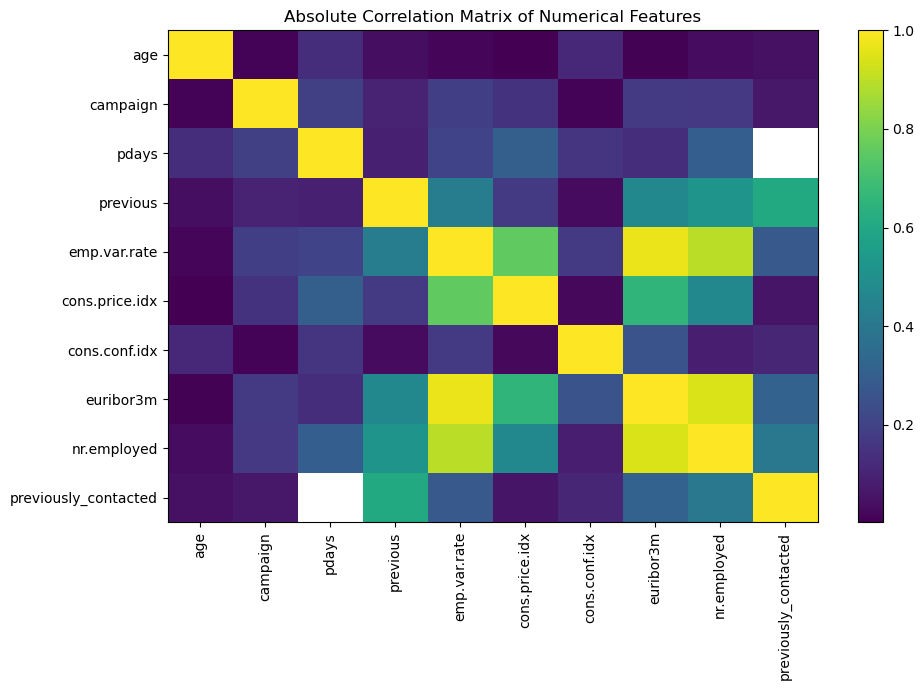

In [18]:
train_num_for_corr = X_train[numerical_features].copy()
corr_matrix = train_num_for_corr.corr().abs()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Absolute Correlation Matrix of Numerical Features")
plt.colorbar()
plt.tight_layout()
plt.show()

In [19]:
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

correlation_threshold = 0.85
high_corr_pairs = []

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and corr_value > correlation_threshold:
            high_corr_pairs.append((row, col, corr_value))

high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "abs_correlation"])
display(high_corr_pairs_df.sort_values("abs_correlation", ascending=False))

,feature_1,feature_2,abs_correlation
0,emp.var.rate,euribor3m,0.969648
2,euribor3m,nr.employed,0.942087
1,emp.var.rate,nr.employed,0.895815


The correlation analysis shows strong relationships among some macroeconomic variables. This is expected because these indicators measure related aspects of the same economic environment.

Rather than aggressively removing many variables based only on pairwise correlation, I make a conservative feature selection choice:

- zero-variance features should be removed automatically if present
- highly correlated features should be acknowledged and discussed
- conceptual leakage is treated as the most important removal criterion in this assignment

This is appropriate here because the assignment emphasizes disciplined reasoning more than aggressive dimensionality reduction.

# Conservative choice: remove only zero-variance features automatically later in the pipeline.
# Correlated features are inspected and discussed, but not forcibly removed here.
# This avoids arbitrary removal of macroeconomic indicators that may still carry distinct signal.

Feature selection must be based on the training set only. If the full dataset were used to decide which features to keep, the validation and test sets would indirectly influence the model design. That would create leakage and invalidate evaluation.

## 9. Addressing Class Imbalance

The target distribution is imbalanced, with many more negative outcomes than positive outcomes. This matters because a classifier could achieve high accuracy simply by predicting the majority class most of the time.

To address this issue, I use **RandomOverSampler** on the training data only. This is a deliberately conservative choice.

I choose random oversampling rather than more complex synthetic methods because the dataset contains many categorical variables that are transformed through one-hot encoding. Random oversampling makes minimal assumptions about feature geometry and does not generate synthetic intermediate samples that might be harder to interpret.

In [20]:
print("Training target counts before resampling:")
display(y_train.value_counts())

print("Training target proportions before resampling:")
display(y_train.value_counts(normalize=True))

Training target counts before resampling:


y
0    2567
1     316
Name: count, dtype: int64

Training target proportions before resampling:


y
0    0.890392
1    0.109608
Name: proportion, dtype: float64

Validation and test sets must preserve the original class distribution. Resampling them would make evaluation unrealistic.

If resampling were applied before splitting, duplicated minority observations could appear in both training and validation or test sets. That would contaminate evaluation and produce overly optimistic results.

## 10. Final Preprocessing Pipeline

At this point, all major design choices have been made:

- `y` is the target
- `duration` has been removed to avoid leakage
- the data has been split before any learned transformation
- `pdays = 999` has been converted into a more principled representation
- `"unknown"` is retained as an informative category
- categorical variables will be one-hot encoded
- numerical variables will be standardized
- zero-variance features will be filtered
- class imbalance will be handled on the training data only using random oversampling

I now combine these steps into a single coherent pipeline.

In [22]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [23]:
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

This pipeline is efficient and leakage-safe:

- the preprocessing steps are fitted on the training data during `fit`
- the oversampler is applied only to the transformed training data
- validation and test data are only transformed, never resampled
- the final classifier receives a fully numeric feature matrix

## 11. Training a Logistic Regression Model

The purpose of this model is not to maximize performance, but to verify that the preprocessing pipeline is coherent and produces sensible predictions.

In [24]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('variance_filter', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
y_val_pred = pipeline.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)

print("Validation Accuracy :", round(val_accuracy, 4))
print("Validation Precision:", round(val_precision, 4))
print("Validation Recall   :", round(val_recall, 4))

Validation Accuracy : 0.8317
Validation Precision: 0.3525
Validation Recall   : 0.6324


Accuracy measures the overall fraction of correct predictions. However, in an imbalanced dataset, accuracy alone can be misleading because it may remain high even when the model performs poorly on the minority class.

Precision measures how often predicted positive cases are actually positive.

Recall measures how many of the actual positive cases are successfully identified.

In the context of a marketing campaign, recall is especially important because missing likely subscribers means missing useful business opportunities.

## 12. Zero Rule Baseline Comparison

The Zero Rule baseline always predicts the majority class observed in the training set. This provides a minimal benchmark against which the Logistic Regression model can be compared.

In [26]:
majority_class = y_train.mode()[0]
y_zero_rule = np.full(shape=len(y_val), fill_value=majority_class)

zero_rule_accuracy = accuracy_score(y_val, y_zero_rule)

print("Zero Rule Accuracy:", round(zero_rule_accuracy, 4))
print("Logistic Regression Accuracy:", round(val_accuracy, 4))
print("Accuracy Difference:", round(val_accuracy - zero_rule_accuracy, 4))

Zero Rule Accuracy: 0.89
Logistic Regression Accuracy: 0.8317
Accuracy Difference: -0.0583


If Logistic Regression does not exceed the Zero Rule baseline in raw accuracy, that does not automatically imply failure. In imbalanced classification, improving recall for the minority class often comes at the cost of lower overall accuracy.

For this reason, the comparison must be interpreted together with precision and recall, not through accuracy alone.

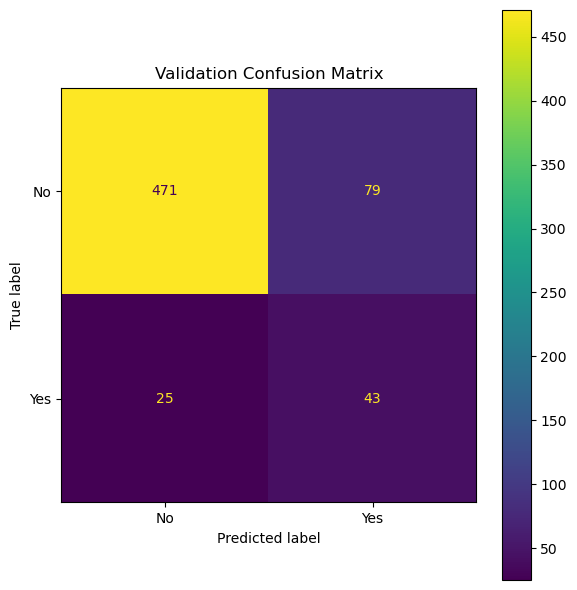

In [27]:
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix makes it possible to inspect false positives and false negatives directly. This is useful because different marketing strategies may value these errors differently.

- A **false positive** corresponds to contacting or prioritizing a client who is not actually likely to subscribe.
- A **false negative** corresponds to failing to identify a client who might have subscribed.

In this application, false negatives may be particularly costly because they represent missed opportunities.

## 13. Task Ordering Justification

The order of tasks in this notebook is deliberate. The assignment listed tasks alphabetically, but the correct methodological order must follow machine learning pipeline discipline.

The sequence used here is:

1. identify the prediction target  
2. load and explore the dataset  
3. screen features conceptually for prediction-time validity  
4. split into training, validation, and test sets  
5. inspect and reason about missingness on the training set  
6. define encoding strategy for categorical variables  
7. define scaling strategy for numerical variables  
8. reason about feature selection using the training set  
9. address class imbalance on training data only  
10. train Logistic Regression and evaluate on validation data

### Why This Order Is Correct

Each step uses only the information that is legitimately available at that stage.

- **Target identification** must come first because the rest of the pipeline depends on knowing the prediction objective.
- **Data exploration** comes next so that the structure of the dataset is understood before transformations are chosen.
- **Conceptual feature screening** must happen early because some variables, such as `duration`, are invalid regardless of their statistical usefulness.
- **Data splitting** must happen before any learned preprocessing to prevent leakage.
- **Missing value handling, encoding, scaling, and feature selection** must be designed using the training set only.
- **Resampling** must be applied only to the training data because it is part of the training procedure.
- **Model training and validation** come last once the pipeline is fully defined.

### What Information Is Allowed and Not Allowed at Each Stage

**1. Identifying the target**  
Allowed: reading the dataset columns and understanding the business objective.  
Not allowed: using outcome information to redesign the problem after modeling.

**2. Data exploration**  
Allowed: descriptive inspection of variables and target distribution.  
Not allowed: fitting transformations on the full dataset.

**3. Conceptual feature screening**  
Allowed: reasoning about whether a feature is available at prediction time.  
Not allowed: keeping a leaked feature because it improves apparent performance.

**4. Data splitting**  
Allowed: stratifying by the target.  
Not allowed: splitting after learned preprocessing.

**5. Missing value handling**  
Allowed: estimating imputation strategy from the training set.  
Not allowed: computing imputation values from the full dataset.

**6. Encoding**  
Allowed: fitting category structure on the training set.  
Not allowed: learning categories from validation or test data.

**7. Scaling**  
Allowed: estimating means and standard deviations from the training set.  
Not allowed: using global statistics from all observations.

**8. Feature selection**  
Allowed: training-set-only correlation and variance analysis.  
Not allowed: selecting features using the full dataset.

**9. Resampling**  
Allowed: balancing the training set.  
Not allowed: resampling validation or test data.

**10. Final evaluation**  
Allowed: predicting on untouched validation data.  
Not allowed: using validation performance to retroactively contaminate preprocessing.

### Example of Incorrect Ordering

An incorrect sequence would be:

1. one-hot encode the full dataset  
2. scale the full dataset  
3. perform feature selection on the full dataset  
4. resample the full dataset  
5. only then split into training, validation, and test sets

This would cause several forms of leakage:

- the scaler would use validation and test statistics
- the encoder would be informed by categories that only appear later
- feature selection would use future information
- oversampled duplicates could end up in both training and validation sets

As a result, the measured performance would be biased upward and would not reflect real generalization ability.

### Example of Incorrect Ordering

An incorrect sequence would be:

1. one-hot encode the full dataset  
2. scale the full dataset  
3. perform feature selection on the full dataset  
4. resample the full dataset  
5. only then split into training, validation, and test sets

This would cause several forms of leakage:

- the scaler would use validation and test statistics
- the encoder would be informed by categories that only appear later
- feature selection would use future information
- oversampled duplicates could end up in both training and validation sets

As a result, the measured performance would be biased upward and would not reflect real generalization ability.

Possible future improvements could include:

- threshold tuning to trade precision against recall more explicitly
- comparing oversampling with alternative methods such as class weighting
- testing whether a subset of correlated macroeconomic variables improves coefficient stability
- evaluating final performance on the untouched test set after all design choices are frozen

However, these extensions are beyond the scope of the present assignment, whose main objective is disciplined data preparation.

## 15. Summary of Design Choices

| Component | Decision | Justification |
|---|---|---|
| Target | `y` | Directly represents subscription outcome |
| Leakage handling | remove `duration` | unavailable at prediction time |
| Missing categorical info | keep `"unknown"` | may carry signal |
| Sentinel numeric value | transform `pdays = 999` | separates no-contact status from elapsed days |
| Train/validation/test split | 70 / 15 / 15 stratified | preserves class distribution |
| Categorical encoding | one-hot encoding | avoids artificial order |
| Numerical scaling | standardization | supports Logistic Regression optimization and regularization |
| Feature selection | conservative, training-set-based | avoids arbitrary removal and leakage |
| Imbalance handling | RandomOverSampler on training data only | simple, robust, and leakage-safe |
| Model | Logistic Regression | sanity check for coherent pipeline |